# PSNR vs Compression Ratio — NYX + WarpX (combined)

Runs the **model-size × SZ3 error-bound** rate–distortion sweep on **both** datasets
and renders one stacked figure: **NYX on top, WarpX on bottom**.

Per point:  `CR = original_target_bytes / (sz_bytes(rel_err) + n_params * 2)`  (params bf16).

- **NYX** — 512³ multi-field. Target `baryon_density` (SZ3-compressed + model-corrected);
  the other 5 fields are conditioning inputs (not compressed, not counted in CR).
- **WarpX** — single-field, stored 256×256×2048 float64 → reoriented to
  `(256, 2048, 256)` (depth = clean **X** axis) so each 2-D slice is the **2048×256**
  (Z×Y) face; normalized to ~[-1,1]. Slicing along X avoids WarpX's guard-plane axis
  (Y, idx 250–255) which NaNs the freq-loss — mirrors `NYX_WARPX.ipynb`.

Each dataset gets its own `REL_ERRS` (spreads CR along x) and `PARAM_TARGETS` (curves).

In [16]:
import random, sys, os, copy, time
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt

sys.path.append("/home/sam/Halo_Finder/Final_design/base_script")

import importlib
import bg_stage
importlib.reload(bg_stage)

from experiment import build_bg_only_cfg, estimate_bg_model_param_bytes
from bg_stage import run_bg_inference, train_bg_only, unwrap_bg_model
from bg_shard import pick_bg_h_under_budget

pysz_dir = "/home/sam/Data_Compression/SZ3/tools/pysz"
if pysz_dir not in sys.path:
    sys.path.append(pysz_dir)
from pysz import SZ

def set_seed(seed=42):
    torch.manual_seed(seed); np.random.seed(seed); random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Device: {device} | GPUs: {torch.cuda.device_count()}")

Device: cuda:0 | GPUs: 1


In [17]:
# ── Shared engine + helpers (identical pipeline for both datasets) ─────────────
halo_finder_root = Path("/home/sam/Halo_Finder")
sz_lib_path = "/home/sam/Data_Compression/SZ3/build/lib64/libSZ3c.so"
sz_engine   = SZ(sz_lib_path)

BYTES_PER_PARAM = 2      # bf16 storage for the model weights
FIXED_LR        = 1e-3
FREQ_WARMUP     = 1      # epochs before the FFT/freq loss term joins the loss
H_CANDIDATES    = list(range(3, 100))

def psnr_from_arrays(target, recon):
    data_range = float(target.max() - target.min())
    if data_range <= 0:
        data_range = 1.0
    mse = float(np.mean((target - recon) ** 2))
    return 100.0 if mse <= 0 else 20.0 * np.log10(data_range) - 10.0 * np.log10(mse)

def build_cfg(Xs_in, Xps_in, max_train_time, bg_h, steps_per_epoch,
              lr=1e-4, epochs=200, log_prefix="", patch_size=None):
    if patch_size is None:
        patch_size = Xs_in[0].shape[2]
    cfg = build_bg_only_cfg(
        X_target=Xs_in[0], Xps=Xps_in, max_train_time=max_train_time,
        epochs=epochs, steps_per_epoch=steps_per_epoch, bg_h=bg_h,
        bg_batch=1, bg_patch_size=patch_size, lr=lr,
    )
    cfg.bg_sample_mode   = "sequential"
    cfg.bg_log_prefix    = log_prefix
    cfg.bg_arch          = "spatial"
    cfg.amp              = True
    cfg.amp_dtype        = "bf16"
    cfg.bg_ddp           = False
    cfg.bg_data_parallel = False
    return cfg

def n_params_of(model):
    return int(sum(p.numel() for p in unwrap_bg_model(model).parameters()))

def build_sweep_plan(param_targets, work_shape, n_fields):
    """Map each param budget -> largest bg_h that fits; dedupe & sort."""
    seen, plan = set(), []
    for tgt in param_targets:
        h, est_p = pick_bg_h_under_budget(
            tgt, shape=work_shape, n_fields=n_fields,
            bg_arch="spatial", h_candidates=H_CANDIDATES,
        )
        if h not in seen:
            seen.add(h)
            plan.append((int(h), int(est_p)))
    plan.sort()
    return plan

def run_sweep(gt, Xs, compress_at, orig_bytes, work_shape,
              rel_errs, sweep_plan, time_per_config, label=""):
    """Full rel-error × model-size sweep for ONE dataset.

    `compress_at(vol, rel)` -> (Xps_list, sz_bytes, sz_cr); Xps_list[0] is the
    SZ3-decompressed target, plus any aux conditioning fields. Only sz_bytes (the
    target stream) is counted in CR. Returns (results, baselines)."""
    depth    = work_shape[0]
    patch_sz = work_shape[2]

    # GPU warm-up (not timed) using the loosest rel_err
    _w_Xps, _, _ = compress_at(gt, max(rel_errs))
    _wcfg = build_cfg(Xs, _w_Xps, max_train_time=0.5, bg_h=4,
                      steps_per_epoch=2, lr=1e-3, epochs=1, log_prefix="warmup")
    set_seed(42)
    train_bg_only(Xs=Xs, Xps=_w_Xps, device=device, cfg=_wcfg,
                  evaluator=lambda m, c=_wcfg: (0.0, 0.0))
    torch.cuda.synchronize() if torch.cuda.is_available() else None
    del _w_Xps
    print(f"[{label}] GPU warm-up done\n")

    results, baselines = [], []
    sweep_t0 = time.time()
    for rel in rel_errs:
        Xps_list, sz_bytes, sz_cr = compress_at(gt, rel)
        base_psnr = psnr_from_arrays(gt, Xps_list[0])
        base_cr   = orig_bytes / sz_bytes
        baselines.append(dict(rel=rel, cr=base_cr, psnr=base_psnr, sz_mb=sz_bytes/1e6))
        print(f"\n{'#'*60}")
        print(f"# [{label}] rel={rel:.0e} | SZ3 base: CR={base_cr:.2f}x "
              f"({sz_bytes/1e6:.2f} MB) | base PSNR={base_psnr:.2f} dB")

        for bg_h, est_p in sweep_plan:
            cfg = build_cfg(Xs, Xps_list, max_train_time=time_per_config, bg_h=bg_h,
                            steps_per_epoch=depth, lr=FIXED_LR, epochs=200,
                            log_prefix=f"{label}-r{rel:.0e}-h{bg_h}", patch_size=patch_sz)
            cfg.bg_early_stop         = False
            cfg.bg_freq_warmup_epochs = FREQ_WARMUP

            def evaluator(m, c=cfg, Xp=Xps_list, rel=rel):
                xh = run_bg_inference(unwrap_bg_model(m), Xs, Xp, c, rel)
                return psnr_from_arrays(gt, xh), 0.0

            set_seed(42)
            model, hist = train_bg_only(Xs=Xs, Xps=Xps_list, device=device,
                                        cfg=cfg, evaluator=evaluator)

            n_params    = n_params_of(model)
            psnr_vals   = [v[1] if isinstance(v, tuple) else v for v in hist.get("psnr", [])]
            psnr        = max(psnr_vals) if psnr_vals else float("nan")
            model_bytes = n_params * BYTES_PER_PARAM
            cr          = orig_bytes / (sz_bytes + model_bytes)
            results.append(dict(rel=rel, bg_h=bg_h, n_params=n_params, psnr=psnr, cr=cr,
                                model_mb=model_bytes/1e6, sz_mb=sz_bytes/1e6,
                                epochs=len(hist.get("loss", []))))
            print(f"  bg_h={bg_h:2d} ({n_params:,}p): PSNR={psnr:.2f} dB | CR={cr:.2f}x "
                  f"(base {base_cr:.2f}x) | +{psnr-base_psnr:.2f} dB over SZ3")
            del model
            torch.cuda.empty_cache() if torch.cuda.is_available() else None

        del Xps_list

    print(f"\n--- [{label}] sweep complete in {(time.time()-sweep_t0)/60:.1f} min "
          f"({len(results)} models over {len(rel_errs)} rel-errors) ---")
    return results, baselines

print("Shared helpers ready")

Shared helpers ready


## NYX — 512³ multi-field (target `baryon_density` + 5 aux conditioning fields)

Only the `baryon_density` SZ3 stream is compressed & counted in CR; the aux fields are
side information fed to the model.

In [18]:
# ── NYX load + config ─────────────────────────────────────────────────────────
nyx_dir      = halo_finder_root / "halo_finder_v1/SDRBENCH-EXASKY-NYX-512x512x512/origin"
NYX_TARGET   = "baryon_density"
NYX_AUX      = ["dark_matter_density", "temperature", "velocity_x", "velocity_y", "velocity_z"]
NYX_PATHS    = {f: (nyx_dir / f"{f}.f32").as_posix() for f in [NYX_TARGET] + NYX_AUX}
NYX_SHAPE    = (512, 512, 512)
NYX_STRIDE   = 1     # >1 to smoke-test the curve shape fast

def _nyx_load_field(name, stride=1):
    vol = np.fromfile(NYX_PATHS[name], dtype=np.float32).reshape(NYX_SHAPE)
    if stride > 1:
        vol = np.ascontiguousarray(vol[::stride, ::stride, ::stride])
    return vol

t0 = time.time()
gt_nyx    = _nyx_load_field(NYX_TARGET, NYX_STRIDE)
aux_nyx   = [_nyx_load_field(f, NYX_STRIDE) for f in NYX_AUX]
Xs_nyx    = [gt_nyx] + aux_nyx                 # field 0 = target
ws_nyx    = gt_nyx.shape
orig_nyx  = gt_nyx.nbytes                      # CR is for the target only

def compress_at_nyx(vol, rel_err):
    b, cr = sz_engine.compress(vol, 1, 0, float(rel_err), 0)
    x_lq  = sz_engine.decompress(b, vol.shape, np.float32).astype(np.float32)
    return [np.asarray(x_lq, np.float32)] + aux_nyx, int(len(b)), float(cr)

# Sweep knobs (NYX compresses very well -> tiny rel-err bounds span a wide CR range)
NYX_TIME_PER_CONFIG = 10
NYX_REL_ERRS        = [1e-6, 3e-6, 5e-6, 7e-6, 9e-6]
NYX_PARAM_TARGETS   = [3000, 6000, 30000, 60000, 90000]
sweep_plan_nyx      = build_sweep_plan(NYX_PARAM_TARGETS, ws_nyx, n_fields=len(Xs_nyx))

print(f"NYX loaded in {time.time()-t0:.1f}s | shape {ws_nyx} (stride={NYX_STRIDE}) | "
      f"target {orig_nyx/1e6:.1f} MB | n_fields={len(Xs_nyx)}")
print(f"REL_ERRS: {NYX_REL_ERRS}")
for h, est_p in sweep_plan_nyx:
    print(f"  bg_h={h:2d}  ~{est_p:,} params")
print(f">> {len(NYX_REL_ERRS)*len(sweep_plan_nyx)} trainings "
      f"(~{len(NYX_REL_ERRS)*len(sweep_plan_nyx)*NYX_TIME_PER_CONFIG/60:.0f} min)")

results_nyx, baselines_nyx = run_sweep(
    gt_nyx, Xs_nyx, compress_at_nyx, orig_nyx, ws_nyx,
    NYX_REL_ERRS, sweep_plan_nyx, NYX_TIME_PER_CONFIG, label="NYX")

del gt_nyx, aux_nyx, Xs_nyx     # free ~3 GB before WarpX (results are just scalars)
torch.cuda.empty_cache() if torch.cuda.is_available() else None


[Model: spatial] Total Params: 859
 [Params] Main (BG) Network : 859 parameters

[Model: spatial] Total Params: 1,396
 [Params] Main (BG) Network : 1,396 parameters

[Model: spatial] Total Params: 2,059
 [Params] Main (BG) Network : 2,059 parameters

[Model: spatial] Total Params: 2,848
 [Params] Main (BG) Network : 2,848 parameters

[Model: spatial] Total Params: 3,763
 [Params] Main (BG) Network : 3,763 parameters

[Model: spatial] Total Params: 4,804
 [Params] Main (BG) Network : 4,804 parameters

[Model: spatial] Total Params: 5,971
 [Params] Main (BG) Network : 5,971 parameters

[Model: spatial] Total Params: 7,264
 [Params] Main (BG) Network : 7,264 parameters

[Model: spatial] Total Params: 8,683
 [Params] Main (BG) Network : 8,683 parameters

[Model: spatial] Total Params: 10,228
 [Params] Main (BG) Network : 10,228 parameters

[Model: spatial] Total Params: 11,899
 [Params] Main (BG) Network : 11,899 parameters

[Model: spatial] Total Params: 13,696
 [Params] Main (BG) Networ

/home/sam/Halo_Finder/Final_design/base_script/bg_stage.py:522: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp, dtype=autocast_dtype):



############################################################
# [NYX] rel=1e-06 | SZ3 base: CR=81.83x (6.56 MB) | base PSNR=129.13 dB

[Model: spatial] Total Params: 2,848
 [Params] Main (BG) Network : 2,848 parameters
NYX-r1e-06-h6 [Init] Epoch   0 | Global PSNR: 129.13 dB | MaxErr: 0.0
NYX-r1e-06-h6 [plan] pure_train_budget=10.00s | epochs_cap=200 | steps/epoch=512 | patch=512 | batch=1 | sample=sequential | data_parallel=False | amp=bf16
NYX-r1e-06-h6 [early-stop] DISABLED (cfg.bg_early_stop is False/unset)
NYX-r1e-06-h6 [gpu-sampling] 6 fields resident on cuda:0 (~6.4 GB)


KeyboardInterrupt: 

## WarpX — single-field, sliced along the clean X axis (2048×256 faces)

Stored `(256,256,2048)` float64 → `(256,2048,256)` float32 `(X, Z, Y)`, normalized to
~[-1,1]. Depth = X, so Y's constant guard planes (idx 250–255) sit as in-plane rows
rather than isolated slices.

In [ ]:
# ── WarpX load + config ───────────────────────────────────────────────────────
WPX_RAW       = (halo_finder_root / "halo_finder_v1/wpx-256_256_2048_double.raw").as_posix()
WPX_SRC_SHAPE = (256, 256, 2048)
WPX_STRIDE    = 1

def _wpx_load(stride=1):
    vol = np.fromfile(WPX_RAW, dtype=np.float64).reshape(WPX_SRC_SHAPE)
    # depth = clean X axis; each slice is the 2048x256 (Z x Y) face.
    vol = np.ascontiguousarray(np.transpose(vol, (1, 2, 0)))    # -> (256, 2048, 256): (X, Z, Y)
    scale = float(np.abs(vol).max()) or 1.0
    vol = (vol / scale).astype(np.float32)                      # ~[-1, 1]
    if stride > 1:
        vol = np.ascontiguousarray(vol[::stride, ::stride, ::stride])
    return vol

t0 = time.time()
gt_wpx   = _wpx_load(WPX_STRIDE)
Xs_wpx   = [gt_wpx]
ws_wpx   = gt_wpx.shape
orig_wpx = gt_wpx.nbytes

def compress_at_wpx(vol, rel_err):
    b, cr = sz_engine.compress(vol, 1, 0, float(rel_err), 0)
    x_lq  = sz_engine.decompress(b, vol.shape, np.float32).astype(np.float32)
    return [np.asarray(x_lq, np.float32)], int(len(b)), float(cr)

WPX_TIME_PER_CONFIG = 10
WPX_REL_ERRS        = [5e-3, 1e-2, 2e-2, 3e-2, 5e-2]
WPX_PARAM_TARGETS   = [3000, 6000, 30000, 60000, 90000]
sweep_plan_wpx      = build_sweep_plan(WPX_PARAM_TARGETS, ws_wpx, n_fields=1)

print(f"WarpX loaded in {time.time()-t0:.1f}s | shape {ws_wpx} (stride={WPX_STRIDE}) | "
      f"{orig_wpx/1e6:.1f} MB | n_fields=1")
print(f"REL_ERRS: {WPX_REL_ERRS}")
for h, est_p in sweep_plan_wpx:
    print(f"  bg_h={h:2d}  ~{est_p:,} params")
print(f">> {len(WPX_REL_ERRS)*len(sweep_plan_wpx)} trainings "
      f"(~{len(WPX_REL_ERRS)*len(sweep_plan_wpx)*WPX_TIME_PER_CONFIG/60:.0f} min)")

results_wpx, baselines_wpx = run_sweep(
    gt_wpx, Xs_wpx, compress_at_wpx, orig_wpx, ws_wpx,
    WPX_REL_ERRS, sweep_plan_wpx, WPX_TIME_PER_CONFIG, label="WarpX")

del gt_wpx, Xs_wpx
torch.cuda.empty_cache() if torch.cuda.is_available() else None


[Model: spatial] Total Params: 724
 [Params] Main (BG) Network : 724 parameters

[Model: spatial] Total Params: 1,216
 [Params] Main (BG) Network : 1,216 parameters

[Model: spatial] Total Params: 1,834
 [Params] Main (BG) Network : 1,834 parameters

[Model: spatial] Total Params: 2,578
 [Params] Main (BG) Network : 2,578 parameters

[Model: spatial] Total Params: 3,448
 [Params] Main (BG) Network : 3,448 parameters

[Model: spatial] Total Params: 4,444
 [Params] Main (BG) Network : 4,444 parameters

[Model: spatial] Total Params: 5,566
 [Params] Main (BG) Network : 5,566 parameters

[Model: spatial] Total Params: 6,814
 [Params] Main (BG) Network : 6,814 parameters

[Model: spatial] Total Params: 8,188
 [Params] Main (BG) Network : 8,188 parameters

[Model: spatial] Total Params: 9,688
 [Params] Main (BG) Network : 9,688 parameters

[Model: spatial] Total Params: 11,314
 [Params] Main (BG) Network : 11,314 parameters

[Model: spatial] Total Params: 13,066
 [Params] Main (BG) Network 

## Combined figure — NYX (top) & WarpX (bottom)

One rate–distortion curve per model size (points span the rel-error sweep) plus the
SZ3-only baseline, for each dataset.

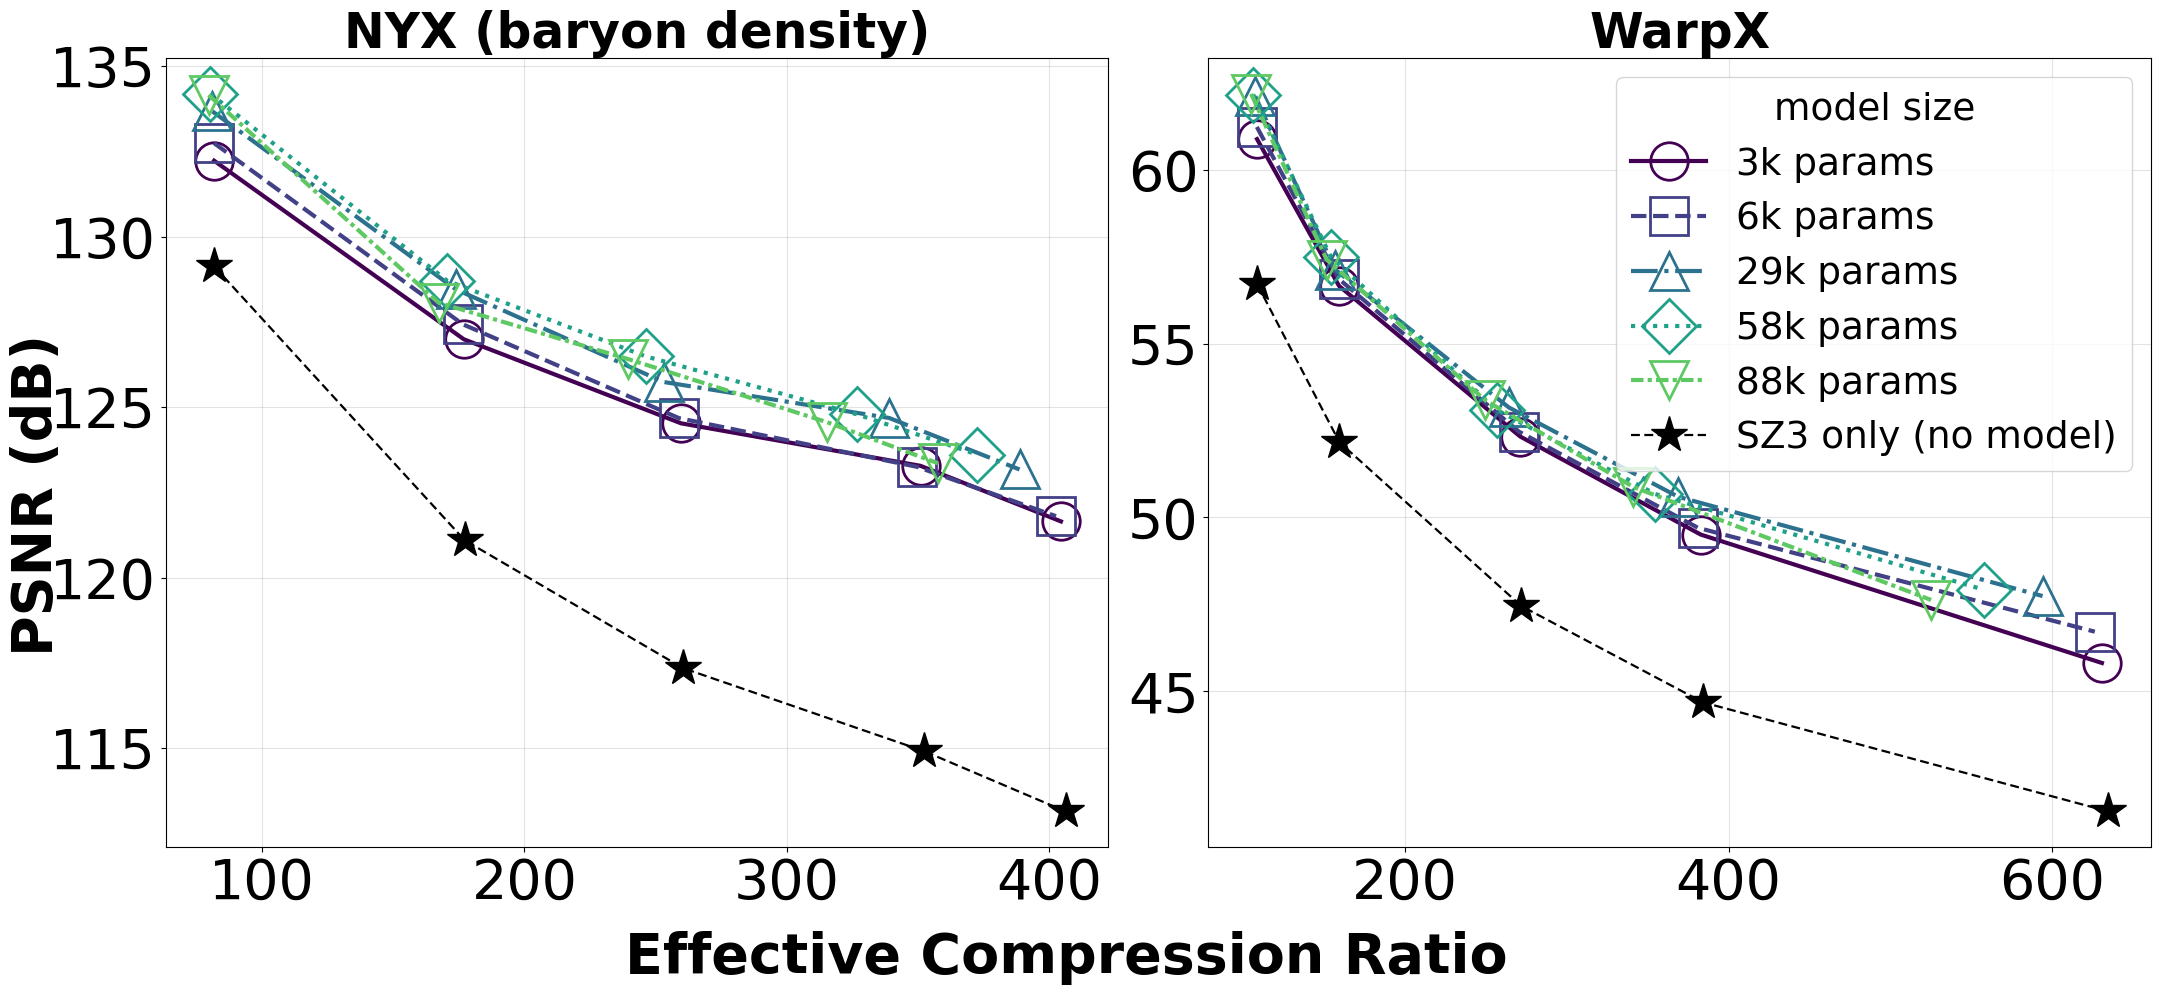

Saved: psnr_vs_cr_relsweep_nyx_warpx.pdf


In [ ]:
MARKERS    = ["o", "s", "^", "D", "v", "P", "X", "*", "<", ">", "h", "p"]
LINESTYLES = ["-", "--", "-.", ":", (0, (3, 1, 1, 1)), (0, (5, 1)), (0, (1, 1))]

def _fmt_p(p):
    return f"{p/1000:.0f}k" if p >= 1000 else str(p)

# 【修改点 1】增加 show_legend 参数
def plot_rd(ax, results, baselines, panel_title, show_legend=True):
    param_sizes = sorted(set(r["n_params"] for r in results))
    cmap   = plt.cm.viridis   # *0.75 keeps off the bright-yellow end
    colors = {p: cmap((i / max(1, len(param_sizes) - 1)) * 0.75)
              for i, p in enumerate(param_sizes)}

    for i, p in enumerate(param_sizes):
        pts = sorted([r for r in results if r["n_params"] == p], key=lambda r: r["cr"])
        ax.plot([r["cr"] for r in pts], [r["psnr"] for r in pts],
                marker=MARKERS[i % len(MARKERS)],
                linestyle=LINESTYLES[i % len(LINESTYLES)],
                color=colors[p], markerfacecolor='none', markeredgewidth=2.0,
                markersize=27, linewidth=3, zorder=3, label=f"{_fmt_p(p)} params")

    bl = sorted(baselines, key=lambda b: b["cr"])
    ax.plot([b["cr"] for b in bl], [b["psnr"] for b in bl],
            marker="*", linestyle=(0, (4, 2)), color="black",
            markersize=27, linewidth=1.6, zorder=2, label="SZ3 only (no model)")

    ax.tick_params(axis='both', which='major', labelsize=40)
    ax.grid(True, alpha=0.35)
    ax.set_title(panel_title, fontsize=35, fontweight='bold')
    
    # 【修改点 2】只在 show_legend 为 True 时显示图例
    if show_legend:
        ax.legend(loc="best", fontsize=27, ncol=1, title="model size", title_fontsize=27)

fig, axes = plt.subplots(1, 2, figsize=(22, 10))

# 【修改点 3】画左图时不显示图例
plot_rd(axes[0], results_nyx, baselines_nyx, "NYX", show_legend=False)
# 画右图时显示图例（默认就是 True）
plot_rd(axes[1], results_wpx, baselines_wpx, "WarpX", show_legend=True)

# 统一设置坐标轴标签
fig.supxlabel("Effective Compression Ratio", fontsize=40, fontweight='bold')
fig.supylabel("PSNR (dB)", fontsize=40, fontweight='bold')

plt.tight_layout()
out_pdf = "psnr_vs_cr_relsweep_nyx_warpx.pdf"
plt.savefig(out_pdf, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {out_pdf}")
